In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df1=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Spam_email_dataset.csv")

In [4]:
df2= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/spam.csv", encoding="latin1")

In [5]:
df1.sample(5)

,label,text
37477,1,amazing frankfurt symbol http sescapenumber bi...
11362,0,"timing is really tight , and am not entirely c..."
30665,1,with penis enlarge patch your penis will grow ...
41246,0,please find below the weekly status update for...
61621,0,john kane wrote how do i make this change i na...


In [6]:
df2.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4963,spam,Dear Voucher holder Have your next meal on us....,NaN,NaN,NaN
1245,ham,Hello which the site to download songs its urg...,NaN,NaN,NaN
3173,ham,It vl bcum more difficult..,NaN,NaN,NaN
4108,ham,I want to lick your pussy now...,NaN,NaN,NaN
3499,spam,Dorothy@kiefer.com (Bank of Granite issues Str...,NaN,NaN,NaN
3171,ham,Do u still have plumbers tape and a wrench we ...,NaN,NaN,NaN
1425,ham,I'll be at mu in like &lt;#&gt; seconds,NaN,NaN,NaN
3678,ham,Stupid.its not possible,NaN,NaN,NaN
3438,ham,"awesome, how do I deal with the gate? Charles ...",NaN,NaN,NaN
2144,spam,FreeMsg: Hey - I'm Buffy. 25 and love to satis...,NaN,NaN,NaN


In [7]:
df1.shape

(83448, 2)

In [8]:
df2.shape

(5572, 5)

## Data Cleaning

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [11]:
df2.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [12]:
df2

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [13]:
df1.rename(columns={'label':'target'},inplace=True)

In [14]:
df2.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [15]:
df2['target'] = df2['target'].apply(lambda x: 0 if x == 'ham' else 1)

In [16]:


df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [17]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  5572 non-null   int64 
 1   text    5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [18]:
spam_data = pd.concat([df1, df2], axis=0, ignore_index=True)

In [19]:
spam_data.shape

(89020, 2)

In [20]:
spam_data= spam_data.sample(frac=1, random_state=42).reset_index(drop=True)

In [21]:
spam_data['target'].value_counts()

,count
target,
1,44657
0,44363


In [22]:
spam_data= spam_data.drop_duplicates(subset='text')

In [23]:
spam_data.shape

(88615, 2)

### EDA

In [24]:
df1['target'].value_counts()

,count
target,
1,43910
0,39538


In [25]:
df2['target'].value_counts()

,count
target,
0,4825
1,747


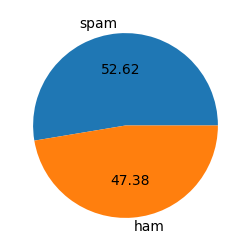

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
plt.pie(df1['target'].value_counts(), labels=['spam','ham'],autopct="%0.2f")
plt.show()

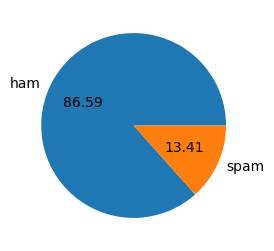

In [27]:
plt.figure(figsize=(3,3))
plt.pie(df2['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

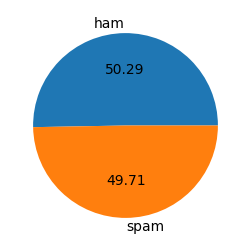

In [28]:
plt.figure(figsize=(3,3))
plt.pie(spam_data['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [29]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [30]:
spam_data['num_characters'] = spam_data['text'].apply(len)

In [31]:
spam_data['num_words'] = spam_data['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [32]:
spam_data['num_sentences'] = spam_data['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [33]:
spam_data.head()

,target,text,num_characters,num_words,num_sentences
0,0,"cera alert : december 13 , 2000\ntitle : calif...",9554,1639,78
1,1,national tobacco survey which do you prefer a ...,1168,178,1
2,0,the feature hasn't been dropped just the info ...,1828,273,1
3,0,Nite...,7,2,1
4,1,balance may blue not door a trade not stitch b...,776,152,1


In [34]:
spam_data[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,88615.000000,88615.000000,88615.000000
mean,1570.595306,269.480032,6.941951
std,4071.899661,708.285219,33.826026
min,1.000000,1.000000,1.000000
25%,373.000000,67.000000,1.000000
50%,806.000000,144.000000,1.000000
75%,1771.500000,300.000000,5.000000
max,598705.000000,101984.000000,3093.000000


In [35]:
# spam
spam_data[spam_data['target']== 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,44053.000000,44053.000000,44053.000000
mean,1911.463964,331.733367,7.489933
std,5403.823914,940.868020,39.944930
min,1.000000,1.000000,1.000000
25%,412.000000,79.000000,1.000000
50%,996.000000,176.000000,1.000000
75%,2020.000000,352.000000,5.000000
max,598705.000000,101984.000000,2827.000000


In [36]:
# ham
spam_data[spam_data['target']== 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,44562.000000,44562.000000,44562.000000
mean,1233.620147,207.937772,6.400229
std,1968.637742,338.935074,26.408220
min,1.000000,1.000000,1.000000
25%,343.000000,59.000000,1.000000
50%,692.000000,120.000000,1.000000
75%,1484.000000,246.000000,4.000000
max,144087.000000,25444.000000,3093.000000


<Axes: xlabel='num_characters', ylabel='Count'>

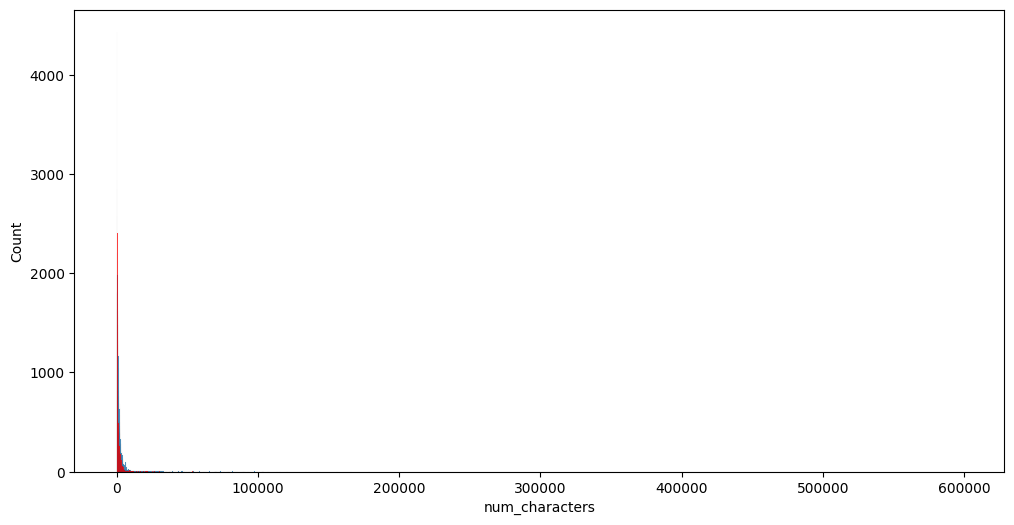

In [37]:
plt.figure(figsize=(12,6))
sns.histplot(spam_data[spam_data['target'] == 0]['num_characters'])
sns.histplot(spam_data[spam_data['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

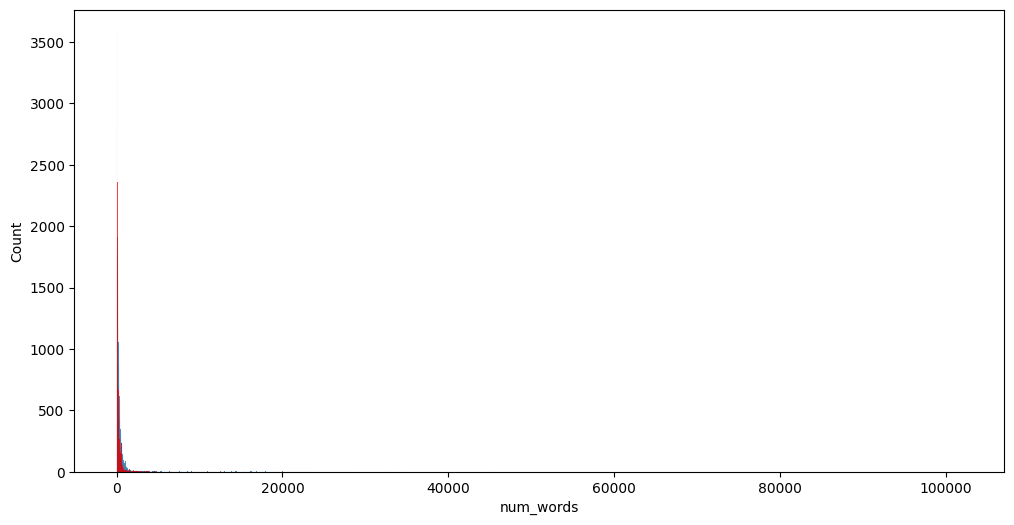

In [38]:
plt.figure(figsize=(12,6))
sns.histplot(spam_data[spam_data['target'] == 0]['num_words'])
sns.histplot(spam_data[spam_data['target'] == 1]['num_words'],color='red')

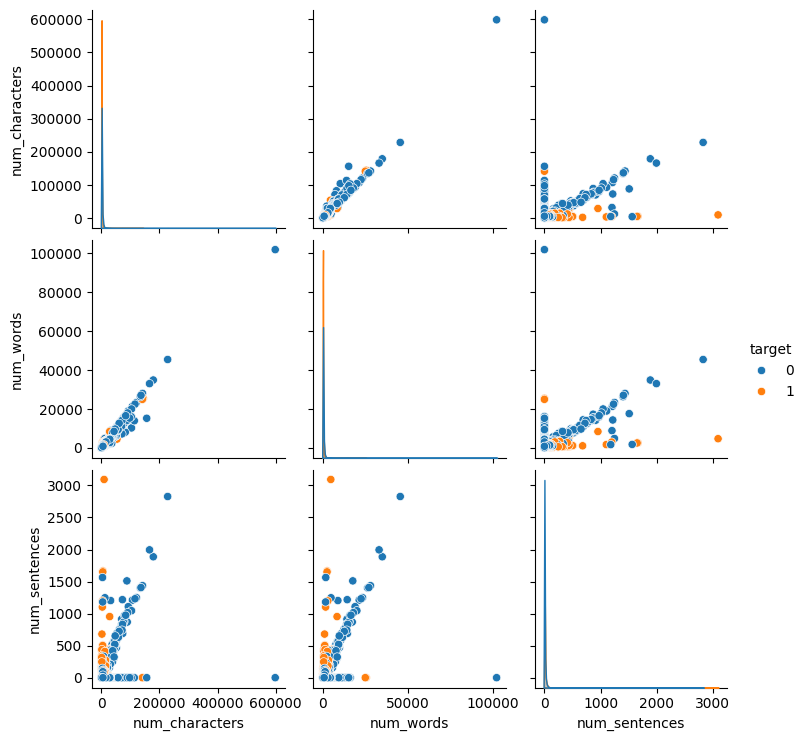

In [39]:
sns.pairplot(spam_data,hue='target')

<Axes: >

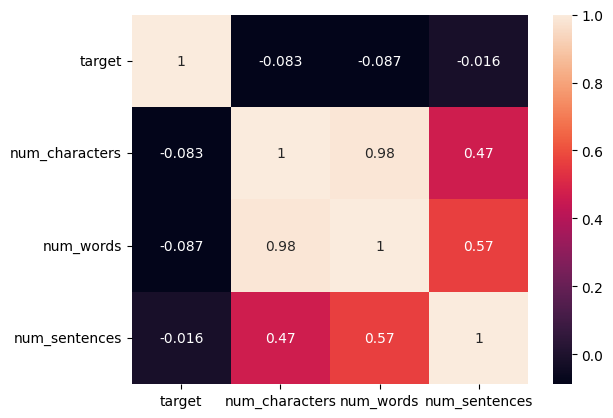

In [40]:
sns.heatmap(spam_data[['target','num_characters','num_words','num_sentences']].corr(),annot=True)

### Data(Text) Preprocessing
##### .. Lower case
##### .. Removing Special Characters
##### .. Removing stop words and punctuation
##### .. Steming

In [41]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer # steming
import string       # string.punctuation

In [42]:
ps = PorterStemmer()

In [43]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [44]:
def transform_text(text):
    text=text.lower()

    words=nltk.word_tokenize(text)

    words = [w for w in words if w.isalnum()]
    words = [w for w in words if w not in stop_words]
    words = [ps.stem(w) for w in words]


    return " ".join(words)

In [45]:
print(transform_text('very well , when you dive , ned , as many times 32 feet of water as there are above you , so many times does your body bear a pressure equal to that of the atmosphere , that is to say , 15 lb\n< a href = " http : / / www . praise 4 m 3 ds . com / index . php ? id = 122 and i give here an extract from a carefully - studied article which i published in the number of the 30 th of april . the human mind delights in grand conceptions of supernatural beings ? the darkness was then profound , and , however good the canadian \' s eyes .'))

well dive ned mani time 32 feet water mani time bodi bear pressur equal atmospher say 15 lb href http www prais 4 3 ds com index php id 122 give extract care studi articl publish number 30 th april human mind delight grand concept supernatur be dark profound howev good canadian eye


In [46]:
spam_data['text'][300]

'very well , when you dive , ned , as many times 32 feet of water as there are above you , so many times does your body bear a pressure equal to that of the atmosphere , that is to say , 15 lb\n< a href = " http : / / www . praise 4 m 3 ds . com / index . php ? id = 122 and i give here an extract from a carefully - studied article which i published in the number of the 30 th of april . the human mind delights in grand conceptions of supernatural beings ? the darkness was then profound , and , however good the canadian \' s eyes .'

In [47]:
from tqdm import tqdm #progress bar dikhane ke liye
tqdm.pandas()

spam_data['transform_text'] = spam_data['text'].progress_apply(transform_text)

100%|██████████| 88615/88615 [06:50<00:00, 215.75it/s]


In [48]:
spam_data[['text','transform_text']].sample(5)

,text,transform_text
25903,the form sought for centuries byi've drifted s...,form sought centuri byi drift somewhat distant...
40475,on fri jun escapenumber escapenumber at escape...,fri jun escapenumb escapenumb escapenumb escap...
75389,send msn list mailing list submissions to msn ...,send msn list mail list submiss msn list te ve...
51382,you can look at the power examp function in th...,look power examp function teachingdemo packag ...
81089,"louise , thanks for your prompt response .\ni ...",louis thank prompt respons get fair respons gu...


In [49]:
spam_data.shape

(88615, 6)

In [50]:
spam_data = spam_data[spam_data['transform_text'] != ""]
spam_data.reset_index(drop=True, inplace=True)

In [51]:
spam_data = spam_data.drop_duplicates(subset='transform_text')
spam_data.reset_index(drop=True, inplace=True)

In [52]:
spam_data.shape

(87932, 6)

### Outliers remove

In [53]:
# for outlier
# spam_data = spam_data[spam_data['num_words'] < 2000]
# word_limit = spam_data['num_words'].quantile(0.99)
# spam_data = spam_data[spam_data['num_words'] <= word_limit]
# spam_data.reset_index(drop=True, inplace=True)

# but here no oultiers after transformation

### Model Building

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [55]:
tfidf = TfidfVectorizer(
    max_features=5000)      # top 5000 important words


In [56]:

X = tfidf.fit_transform(spam_data['transform_text']).toarray()

In [57]:
y = spam_data['target']

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [60]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()
lrc = LogisticRegression(solver='liblinear', penalty='l1')
lsv = LinearSVC()

In [61]:
clfs = {
    'GNB': gnb,
    'MNB': mnb,
    'BNB':bnb,
    'LR': lrc,
    'LinearSVC':lsv,
}

In [62]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test,y_pred)
    prec = precision_score(y_test,y_pred)

    return acc,prec

In [63]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  GNB
Accuracy -  0.9310286006709502
Precision -  0.9011162594776748
For  MNB
Accuracy -  0.9325069653721498
Precision -  0.9151640234629589
For  BNB
Accuracy -  0.8836072098709273
Precision -  0.834253054789121
For  LR
Accuracy -  0.9633251833740831
Precision -  0.9652193680381905
For  LinearSVC
Accuracy -  0.9653721498834367
Precision -  0.9681166021407425


In [64]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(lrc,open('model.pkl','wb'))